## E1 - Phân loại Softmax, MLP, CNN

- Dataset lựa chọn: **Fashion MNIST**
- Đặc điểm dataset Fashion-MNIST:
  - Gồm 70,000 ảnh grayscale
  - Kích thước: $28 \times 28$
  - Số ảnh train: 60,000
  - Số ảnh test: 10,000
  - Số lớp phân loại: 10

|Label|Name|
|-|-|
|0|T-shirt/top|
|1|Trouser|
|2|Pullover|
|3|Dress|
|4|Coat|
|5|Sandal|
|6|Shirt|
|7|Sneaker|
|8|Bag|
|9|Ankle boot|

In [30]:
import os
import random
import struct
import time
import copy

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from typing import Tuple
from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import confusion_matrix
from matplotlib.lines import Line2D

In [ ]:
# Common function

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_device() -> torch.device:
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

In [9]:
# Config

CONFIG = {
    "dataset": "FashionMNIST",
    "data_dir": Path("../../fashion-mnist"),
    "seed": 42,
    "val_ratio": 0.1, # 10%
    "batch_size": 128,
    "epochs": 50,
    "optimizer": "adam",
    "lr": 1e-3,
    "weight_decay": 0.0,
    "metric": "val_accuracy",
    "patience": 5,
}

set_seed(CONFIG["seed"])
DEVICE = get_device()

In [10]:
# Fashion-MNIST Dataset supporter

def read_idx(filename: str) -> np.ndarray:
    """Read an IDX file and return it as a NumPy array."""
    with open(filename, "rb") as f:
        zero, data_type, dims = struct.unpack(">HBB", f.read(4))
        shape = tuple(struct.unpack(">I", f.read(4))[0] for _ in range(dims))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(shape)


def load_fashion_mnist(data_dir: Path) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Load the Fashion-MNIST dataset from the specified directory following Github repository structure."""
    train_images = read_idx(data_dir / "train-images-idx3-ubyte")
    train_labels = read_idx(data_dir / "train-labels-idx1-ubyte")
    test_images = read_idx(data_dir / "t10k-images-idx3-ubyte")
    test_labels = read_idx(data_dir / "t10k-labels-idx1-ubyte")
    return train_images, train_labels, test_images, test_labels

train_images, train_labels, test_images, test_labels = load_fashion_mnist(CONFIG["data_dir"])

## The first speech.
## print the shapes of the loaded datasets
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

lb_set = np.unique(train_labels).tolist()
print("Unique labels in the training set:", lb_set)

print("Pixel range:", train_images.min(), "to", train_images.max())
print("Test pixel range:", test_images.min(), "to", test_images.max())

Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)
Unique labels in the training set: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Pixel range: 0 to 255
Test pixel range: 0 to 255


In [11]:
# Fashion-MNIST configurations

## List of class names for the Fashion MNIST dataset
## according to Github
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

NUM_CLASSES = len(CLASS_NAMES)
IMAGE_SHAPE = (1, 28, 28)             # (C, H, W)
INPUT_DIM = int(np.prod(IMAGE_SHAPE)) # flattened size

# print
print("Number of classes:", NUM_CLASSES)
print("Image shape:", IMAGE_SHAPE)
print("Input dimension (flattened):", INPUT_DIM)

Number of classes: 10
Image shape: (1, 28, 28)
Input dimension (flattened): 784


In [ ]:
# Dataset split

SPLIT_PATH = Path(f"split_indices_seed{CONFIG['seed']}.npz")

if SPLIT_PATH.exists():
    # Reuse the saved split so later experiments use exactly the same samples
    with np.load(SPLIT_PATH) as split_indices:
        assert int(split_indices['seed']) == CONFIG['seed'], "Saved split seed does not match the current CONFIG['seed']"
        train_indices = split_indices['train_indices']
        val_indices = split_indices['val_indices']
else:
    all_indices = np.arange(len(train_labels))
    train_indices, val_indices = train_test_split(
        all_indices, 
        test_size=CONFIG['val_ratio'], 
        random_state=CONFIG['seed'],
        stratify=train_labels,  # Ensure the split maintains the label distribution
        shuffle=True,
    )
    train_indices, val_indices = np.sort(train_indices), np.sort(val_indices)
    np.savez(SPLIT_PATH, seed=CONFIG['seed'], train_indices=train_indices, val_indices=val_indices)

X_train, y_train = train_images[train_indices], train_labels[train_indices]
X_val, y_val = train_images[val_indices], train_labels[val_indices]
X_test, y_test = test_images, test_labels

## print shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (48000, 28, 28)
y_train shape: (48000,)
X_val shape: (12000, 28, 28)
y_val shape: (12000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [13]:
# Plot support functions

## Location
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

## Define color palette for plots
BLUE, BLUE_DARK, GRAY = "#2a78d6", "#104281", "#c9c8c3"

## Update plt params
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#8a8984",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "axes.grid": False,
    "grid.color": "#e6e5e0",
    "grid.linewidth": 0.8,
    "font.size": 9,
})

def save_fig(fig, name: str) -> None:
    fig.savefig(FIG_DIR / f"{name}.png")

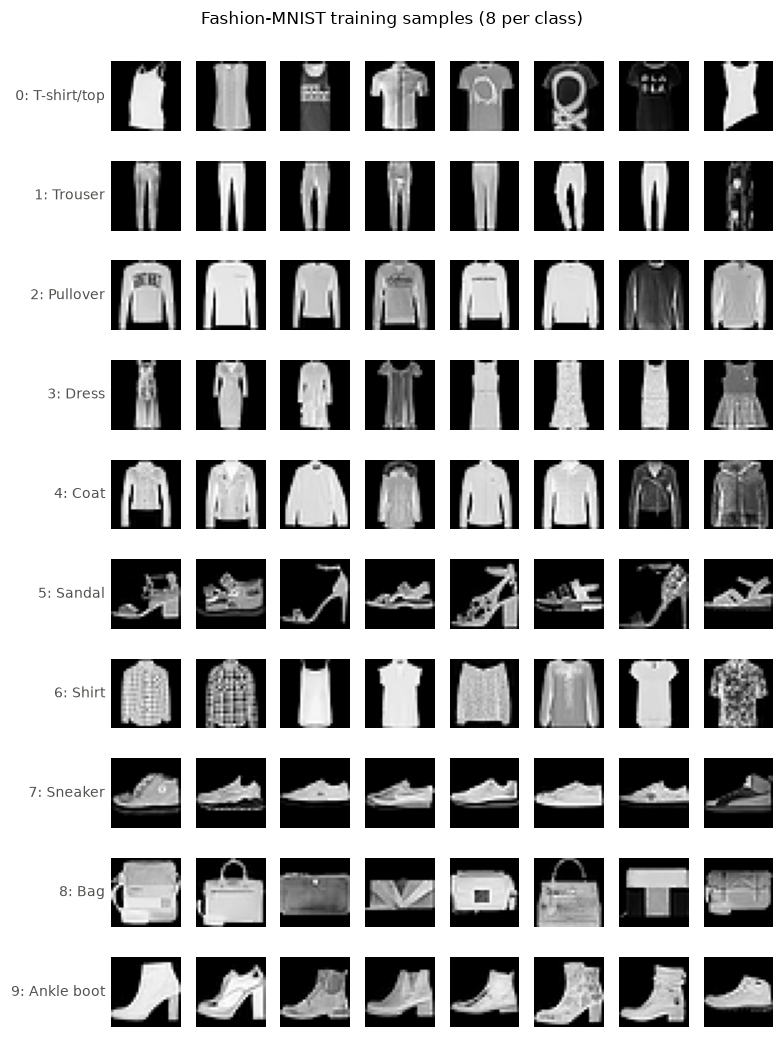

In [14]:
# Data exploration

SAMPLES_PER_CLASS = 8
rng = np.random.default_rng(CONFIG["seed"])

fig, axes = plt.subplots(NUM_CLASSES, SAMPLES_PER_CLASS, figsize=(SAMPLES_PER_CLASS * 0.9, NUM_CLASSES * 0.95))
for k, name in enumerate(CLASS_NAMES):
    picks = rng.choice(np.flatnonzero(y_train == k), SAMPLES_PER_CLASS, replace=False)
    for j, i in enumerate(picks):
        ax = axes[k, j]
        ax.imshow(X_train[i], cmap="gray", vmin=0, vmax=255)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    axes[k, 0].set_ylabel(f"{k}: {name}", rotation=0, ha="right", va="center", fontsize=9)
fig.suptitle("Fashion-MNIST training samples (8 per class)", y=0.995)
fig.tight_layout()
save_fig(fig, "E0_samples_per_class")
plt.show()

In [15]:
# Pixel statistics

X_train_f = X_train.astype(np.float32) / 255.0   # scale to [0, 1], as ToTensor() will
pixel_mean = X_train_f.mean()
pixel_std = X_train_f.std()
zero_frac = (X_train == 0).mean()

print(f"Pixel mean (train, [0,1] scale): {pixel_mean:.4f}")
print(f"Pixel std  (train, [0,1] scale): {pixel_std:.4f}")
print(f"Fraction of exactly-zero pixels : {zero_frac:.1%}")

NORM_MEAN, NORM_STD = float(pixel_mean), float(pixel_std)

Pixel mean (train, [0,1] scale): 0.2863
Pixel std  (train, [0,1] scale): 0.3532
Fraction of exactly-zero pixels : 50.2%


In [16]:
# Normalized pixel statistics

def preprocess(images: np.ndarray) -> torch.Tensor:
    # uint8 [N, 28, 28] -> normalized float32 [N, 1, 28, 28]
    x = torch.tensor(images, dtype=torch.float32).div(255.0).unsqueeze(1)
    return (x - NORM_MEAN) / NORM_STD

train_ds = TensorDataset(preprocess(X_train), torch.tensor(y_train, dtype=torch.long))
val_ds = TensorDataset(preprocess(X_val), torch.tensor(y_val, dtype=torch.long))
test_ds = TensorDataset(preprocess(X_test), torch.tensor(y_test, dtype=torch.long))

In [17]:
# Dataloaders

def make_train_loader(seed: int) -> DataLoader:
    """A fresh generator with the same seed gives every model the same mini-batch order"""
    return DataLoader(
        train_ds, 
        batch_size=CONFIG["batch_size"], 
        shuffle=True,
        generator=torch.Generator().manual_seed(seed)
    )

# Unshuffled loaders for evaluation; train_eval_loader measures train accuracy in eval mode
train_eval_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"])
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"])
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"])

images, labels = next(iter(make_train_loader(CONFIG["seed"])))
flattened_images = images.flatten(start_dim=1)

print(f"Input data (B, C, H, W)   : ", tuple(images.shape))
print(f"Flattened input (B, C*H*W): ", tuple(flattened_images.shape))

Input data (B, C, H, W)   :  (128, 1, 28, 28)
Flattened input (B, C*H*W):  (128, 784)


## Softmax Classifier

Linear mapping (Logits): input vector x, weights W, bias b
$$z = Wx + b$$

Softmax Transformation:
$$P(y=i|x) = \frac{e^{z_i}}{\sum_j{e^{z_j}}}$$

In [18]:
# Softmax Classifier (Manual Implementation)

# def softmax(logits):
#     # Numerical stability: subtract max per row
#     exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
#     return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

# def cross_entropy_loss(probabilities, y):
#     m = y.shape[0]
#     # Take the negative log probability of the correct class
#     log_probs = -np.log(probabilities[range(m), y] + 1e-9)
#     return np.sum(log_probs) / m

# class SoftmaxClassifierManual():

#     def __init__(self, lr=0.1, num_classes=10, num_features=784):
#         super().__init__()
#         self.lr = lr
#         self.weights = np.random.randn(num_features, num_classes) * 0.01
#         self.bias = np.zeros((1, num_classes))

#     def train(self, X, y, epochs=1000):
#         m = X.shape[0]
#         for epoch in range(epochs):
#             # 1. Linear mapping, like nn.forward
#             logits = np.dot(X, self.weights) + self.bias
            
#             # 2. Softmax to get prob
#             probabilities = softmax(logits)
            
#             # 3. Compute loss
#             loss = cross_entropy_loss(probabilities, y)
            
#             # 4. Backward
#             grad_logits = probabilities.copy()
#             grad_logits[range(m), y] -= 1
#             grad_logits /= m

#             dW = np.dot(X.T, grad_logits)
#             db = np.sum(grad_logits, axis=0, keepdims=True)

#             # 5. Update weights and bias
#             self.weights -= self.lr * dW
#             self.bias -= self.lr * db

#             if epoch % 10 == 0:
#                 print(f"Epoch {epoch}, Loss: {loss:.4f}")

#     def predict(self, X):
#         logits = np.dot(X, self.weights) + self.bias
#         probabilities = softmax(logits)
#         return np.argmax(probabilities, axis=1)

In [19]:
# Softmax Classifier

class SoftmaxClassifier(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, num_classes=NUM_CLASSES):
        super().__init__()
        self.flatten = nn.Flatten()                   # [B, 1, H, W] -> [B, H*W]
        self.fc = nn.Linear(input_dim, num_classes)   # [10, 784], b: [10]

    def forward(self, x):
        return self.fc(self.flatten(x))               # logits z, chưa softmax

    @torch.no_grad()
    def predict_proba(self, x):
        self.eval()
        return torch.softmax(self(x), dim=1)          # P(y=i|x) = exp(z_i) / sum_j exp(z_j)

## MLP Classifier



In [31]:
# MLP Classifier

class MLPClassifier(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dims=(512, 256), num_classes=NUM_CLASSES, dropout=0.2):
        super().__init__()
        layers = [nn.Flatten()]                             # [B,1,28,28] -> [B,784]
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))  # layer 1: z1 = xW + b
            layers.append(nn.ReLU())                        # activation function after linear layer
                                                            #     layer 2: a1 = ReLU(z1)
            layers.append(nn.Dropout(dropout))              # dropout layer để tránh overfitting
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, num_classes))     # trả về số lớp cuối cùng (logits)
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)                                # không gọi softmax để tránh việc softmax bị tính 2 lần

    @torch.no_grad()
    def predict_proba(self, x):
        self.eval()
        return torch.softmax(self(x), dim=1)               # P(y=i|x) = exp(z_i) / sum_j exp(z_j)

## CNN Classifier

- Nhận ảnh nguyên dạng [B, 1, 28, 28] - không flatten
- Mô hình có hai phần:
  - Feature extractor: các khối convolution
  - Head: flatten rồi qua các tầng linear, trả về logits

In [21]:
# CNN Classifier

def conv_block(in_channels, out_channels, kernel_size=3, stride=1, padding=1, pool_kernel=2, pool_stride=2):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=pool_kernel, stride=pool_stride)
    )

class CNNClassifier(nn.Module):

    def __init__(
        self, 
        input_channels=IMAGE_SHAPE[0], # 1 
        channel_dims=(32, 64), 
        hidden_dim=128, 
        num_classes=NUM_CLASSES, 
        dropout=0.2,
        ):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(input_channels, channel_dims[0]),    # [B, 1, H, W] -> [B, 32, H/2, W/2]
                                                            # [B, 1, 28, 28] -> [B, 32, 14, 14]
            conv_block(channel_dims[0], channel_dims[1]),   # [B, 32, H/2, W/2] -> [B, 64, H/4, W/4]
                                                            # [B, 32, 14, 14] -> [B, 64, 7, 7]
        )
        spatial = IMAGE_SHAPE[1] // 2 ** len(channel_dims)  # 28 / 4 = 7 after two conv_blocks
        
        # head (fully connected classifier)
        self.classifier = nn.Sequential(
            nn.Flatten(),                                   # [B, 64, 7, 7] -> [B, 64*7*7] = [B, 3136]
            nn.Dropout(dropout),
            nn.Linear(channel_dims[-1] * spatial * spatial, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )
    
    def forward(self, x):
        return self.classifier(self.features(x))
    
    @torch.no_grad()
    def predict_proba(self, x):
        self.eval()
        return torch.softmax(self(x), dim=1)

## Training loop

In [ ]:
def run_epoch(model, dataloader, criterion, optimizer=None, device='cpu'):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, correct, n = 0.0, 0, 0
    
    with torch.set_grad_enabled(is_train):
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)                   # forward
            loss = criterion(logits, y)         # compute loss
            if is_train:
                optimizer.zero_grad()
                loss.backward()                 # backward pass
                optimizer.step()                # cập nhật trọng số
            
            total_loss += loss.item() * y.size(0)
            correct += (logits.argmax(dim=1) == y).sum().item()
            n += y.size(0)
    return total_loss / n, correct / n
  
def fit(model, epochs=CONFIG["epochs"], learning_rate=CONFIG["lr"], 
        weight_decay=CONFIG["weight_decay"], seed=CONFIG["seed"], patience=CONFIG["patience"], device='cpu'):
    set_seed(seed)
    model.to(device)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    train_loader = make_train_loader(seed)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "epoch_time": []}
    best_acc, best_state, best_epoch, bad = -1.0, None, 0, 0
    
    for epoch in range(epochs):
        start = time.perf_counter()
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer=optimizer, device=device)
        epoch_time = time.perf_counter() - start
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None, device=device)
        
        for k, v in zip(history, (train_loss, train_acc, val_loss, val_acc, epoch_time)):
            history[k].append(v)
        
        print(f"Epoch {epoch+1}/{epochs} - "
              f"Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f} - "
              f"Val loss: {val_loss:.4f}, Val acc: {val_acc:.4f}")        
        
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            bad = 0
        else:
            bad += 1
        
        if bad >= patience:
            break
    
    if best_state is not None:
        model.load_state_dict(best_state)
    
    return history, best_epoch

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Evaluate

In [35]:
@torch.no_grad()
def collect_outputs(model, dataloader, device='cpu'):
    """Trả về y_true, y_pred, probs theo đúng thứ tự của loader (loader không shuffle)."""
    model.eval()
    all_outputs, all_labels = [], []
    for x, y in dataloader:
        x = x.to(device)
        logits = model(x)
        softmax = torch.softmax(logits, dim=1)
        all_outputs.append(softmax.cpu())
        all_labels.append(y)
    probs = torch.cat(all_outputs, dim=0).numpy()
    labels = torch.cat(all_labels, dim=0).numpy()
    return labels, probs.argmax(axis=1), probs      # tương đương với y_true, y_pred, probs
  
def evaluate_model(model, name, best_epoch, train_time, device='cpu'):
    """Đánh giá mô hình trên các tập dữ liệu và trả về một dictionary chứa thông tin cần thiết"""
    criterion = torch.nn.CrossEntropyLoss()
    row = {
      "model": name,
      "params": count_parameters(model),
      "best_epoch": best_epoch,
      "train_time": train_time,
    }
    for split, loader in [("train", train_eval_loader), ("val", val_loader), ("test", test_loader)]:
        loss, acc = run_epoch(model, loader, criterion, None, device)
        row[f"{split}_loss"] = loss
        row[f"{split}_acc"] = acc
    return row

In [36]:
MODELS = {
  "Softmax": SoftmaxClassifier,
  "MLP": MLPClassifier,
  "CNN": CNNClassifier,
}

results, histories, trained, outputs = [], {}, {}, {}

for name, cls in MODELS.items():
    print(f"Classifier name: {name}")
    set_seed(CONFIG["seed"])
    model = cls()
    t0 = time.perf_counter()
    histories[name], best_epoch = fit(model, device=DEVICE)
    histories[name]["train_time"] = time.perf_counter() - t0
    trained[name] = model
    outputs[name] = collect_outputs(model, test_loader, device=DEVICE)
    evaluation = evaluate_model(model, name, best_epoch, histories[name]["train_time"], device=DEVICE)
    results.append(evaluation)
    
# print results
header = f"{'Model':<9}{'Params':>10}{'Best ep':>9}{'Time(s)':>9}{'Train':>9}{'Val':>9}{'Test':>9}"
print(header); print("-" * len(header))
for r in results:
    print(f"{r['model']:<9}{r['params']:>10,}{r['best_epoch']:>9}{r['train_time']:>9.1f}"
          f"{r['train_acc']:>9.2%}{r['val_acc']:>9.2%}{r['test_acc']:>9.2%}")

Classifier name: Softmax
Epoch 1/50 - Train loss: 0.5870, Train acc: 0.7974 - Val loss: 0.4592, Val acc: 0.8411
Epoch 2/50 - Train loss: 0.4604, Train acc: 0.8403 - Val loss: 0.4253, Val acc: 0.8559
Epoch 3/50 - Train loss: 0.4370, Train acc: 0.8478 - Val loss: 0.4188, Val acc: 0.8552
Epoch 4/50 - Train loss: 0.4253, Train acc: 0.8517 - Val loss: 0.4169, Val acc: 0.8556
Epoch 5/50 - Train loss: 0.4181, Train acc: 0.8546 - Val loss: 0.4131, Val acc: 0.8580
Epoch 6/50 - Train loss: 0.4108, Train acc: 0.8573 - Val loss: 0.4196, Val acc: 0.8533
Epoch 7/50 - Train loss: 0.4083, Train acc: 0.8571 - Val loss: 0.4040, Val acc: 0.8599
Epoch 8/50 - Train loss: 0.4035, Train acc: 0.8586 - Val loss: 0.4096, Val acc: 0.8570
Epoch 9/50 - Train loss: 0.3985, Train acc: 0.8606 - Val loss: 0.4181, Val acc: 0.8568
Epoch 10/50 - Train loss: 0.3976, Train acc: 0.8602 - Val loss: 0.4021, Val acc: 0.8611
Epoch 11/50 - Train loss: 0.3933, Train acc: 0.8617 - Val loss: 0.4093, Val acc: 0.8580
Epoch 12/50 - Tr

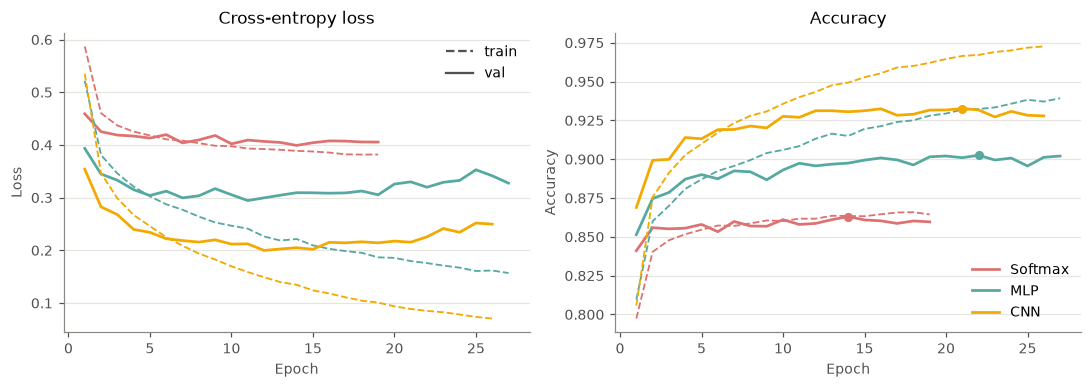

In [43]:
# Learning Curves
## Plot learning curves for all models

MODEL_COLORS = {"Softmax": "#DE7272", "MLP": "#55A9A0", "CNN": "#F2A900"}

def plot_learning_curves(histories):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
    for name, h in histories.items():
        epochs = np.arange(1, len(h["val_loss"]) + 1)
        color = MODEL_COLORS[name]
        for ax, key in zip(axes, ["loss", "acc"]):
            ax.plot(epochs, h[f"train_{key}"], color=color, ls="--", lw=1.2)
            ax.plot(epochs, h[f"val_{key}"], color=color, lw=1.8, label=name)
        best = int(np.argmax(h["val_acc"]))
        axes[1].scatter(best + 1, h["val_acc"][best], color=color, s=25, zorder=3)  # checkpoint được chọn

    axes[0].set(title="Cross-entropy loss", xlabel="Epoch", ylabel="Loss")
    axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
    for ax in axes:
        ax.grid(True, axis="y")
    style = [Line2D([], [], color="#52514e", ls="--", label="train"),
             Line2D([], [], color="#52514e", label="val")]
    axes[0].legend(handles=style, frameon=False)
    axes[1].legend(frameon=False, loc="lower right")
    fig.tight_layout()
    return fig

fig = plot_learning_curves(histories)
save_fig(fig, "E1_learning_curves")
plt.show()

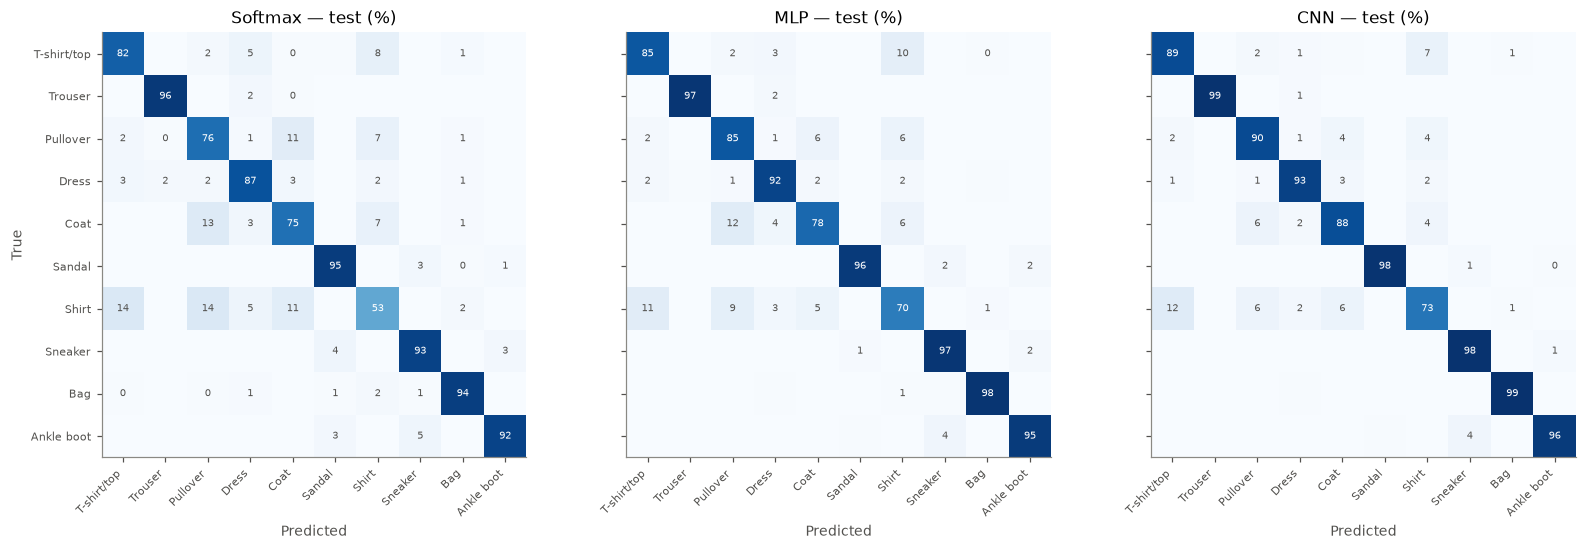

In [38]:
# Confusion Matrix

def plot_confusion_matrix(y_true, y_pred, title, ax, show_ylabels=True):
    cm = confusion_matrix(y_true, y_pred, labels=range(NUM_CLASSES), normalize="true")  # chuẩn hoá theo hàng
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            if cm[i, j] >= 0.005:                       # ẩn các ô ≈ 0 cho dễ nhìn
                ax.text(j, i, f"{cm[i, j] * 100:.0f}", ha="center", va="center", fontsize=6.5,
                        color="white" if cm[i, j] > 0.5 else "#52514e")
    ax.set_xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(NUM_CLASSES), CLASS_NAMES if show_ylabels else [], fontsize=7)
    ax.set(xlabel="Predicted", title=title)
    if show_ylabels:
        ax.set_ylabel("True")
    return cm

fig, axes = plt.subplots(1, len(outputs), figsize=(5 * len(outputs), 4.8))
cms = {}
for k, (ax, (name, (y_true, y_pred, _))) in enumerate(zip(axes, outputs.items())):
    cms[name] = plot_confusion_matrix(y_true, y_pred, f"{name} — test (%)", ax, show_ylabels=(k == 0))
fig.tight_layout()
save_fig(fig, "E1_confusion_matrices")
plt.show()

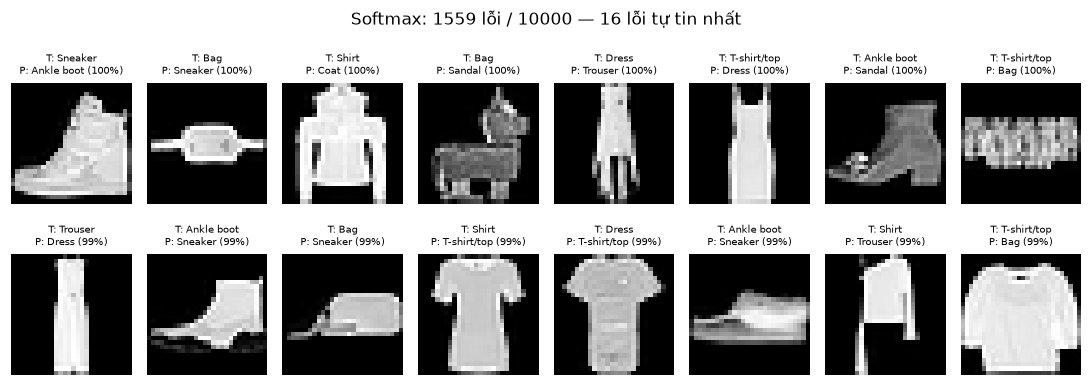

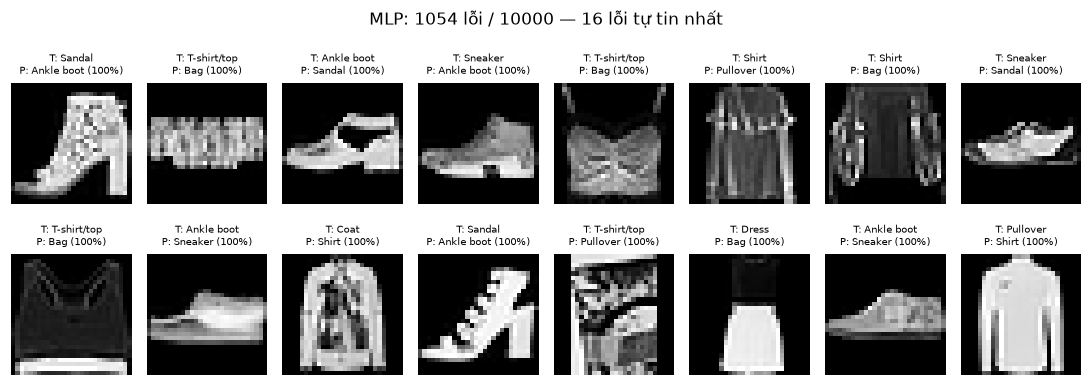

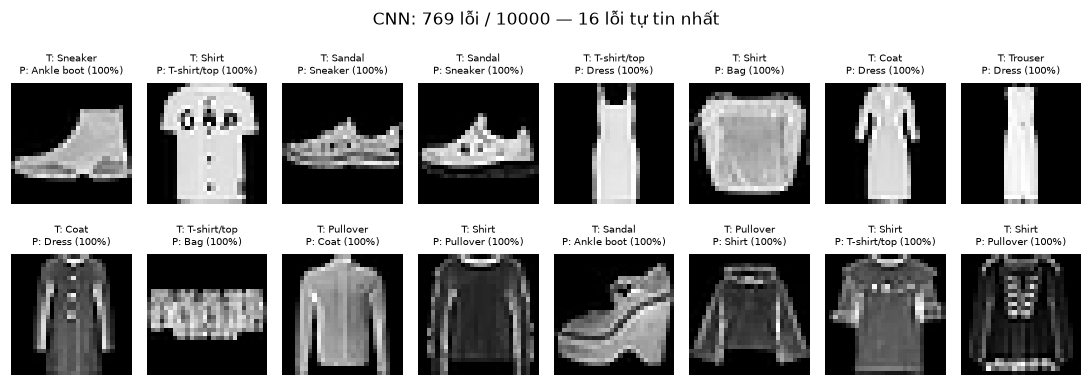

In [42]:
# Mẫu sai

def plot_misclassified(y_true, y_pred, probs, title, n=16, cols=8):
    wrong = np.flatnonzero(y_pred != y_true)
    conf = probs[wrong, y_pred[wrong]]
    wrong = wrong[np.argsort(-conf)][:n]                # các lỗi mà model tự tin nhất
    rows = int(np.ceil(len(wrong) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.25, rows * 1.9), squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for ax, i in zip(axes.flat, wrong):
        ax.imshow(X_test[i], cmap="gray", vmin=0, vmax=255)
        ax.set_title(f"T: {CLASS_NAMES[y_true[i]]}\nP: {CLASS_NAMES[y_pred[i]]} ({probs[i, y_pred[i]]:.0%})",
                     fontsize=6.5)
    fig.suptitle(f"{title}: {np.sum(y_pred != y_true)} lỗi / {len(y_true)} — {len(wrong)} lỗi tự tin nhất")
    fig.tight_layout()
    return fig

for name, (y_true, y_pred, probs) in outputs.items():
    fig = plot_misclassified(y_true, y_pred, probs, name)
    save_fig(fig, f"E1_misclassified_{name.lower()}")
    plt.show()

## Nhận xét

Table 1. Bảng kết quả chạy của ba bộ phân loại

| Cls | Params | Best epoch | Train time | Train acc | Val acc | Test acc | Test error |
| --- | ------ | ---------- | ---------- | --------- | ------- | -------- | ---------- |
|Softmax|7,850|14|2.9|87.03%|86.31%|84.41%|1,559|
|MLP|538,818|22|13.8|95.19%|   90.26%|   89.46%|1,054|
|CNN|421,642|21|   217.1|   98.49%|  93.27%|   92.31%|769|

---

### Dựa theo Learning Curves

#### Softmax

- Underfit, đường train và val gần như trùng nhau. Ở loss thì dao động quanh 0.4, còn ở accuracy thì chững lại ở khoảng 86% chỉ sau vài epoch đầu (sau đó tiếp tục đi ngang).

- Train thêm cũng không cải thiện.

#### MLP

- Overfit, nhìn vào đồ thị loss, val loss đạt đáy rồi đi lên trong khi train loss vẫn tiếp tục giảm. Hai đường tách xa nhau dần, val loss thấp nhất khoảng 0.295 sau đó tăng, trong khi train loss giảm đều từ 0.3 -> 0.16.

- Nhìn qua đồ thị accuracy, cho thấy hậu quả của overfit, val acc đứng ưng trong khi train acc tiếp tục tăng tạo ra khoảng cách. Ở thời điểm dừng, khoảng cách train-val accuracy (đo ở chế độ eval) là khoảng 4.9 điểm.

#### CNN

- Overfit. Về hai đồ thị loss/accuracy trong learning curves của CNN tương tự với MLP. Thậm chí, so với MLP thì CNN còn overfit mạnh hơn một chút do train loss giảm sâu hơn, val loss tăng nhiều hơn tính theo tỉ lệ và khoảng cách train-val lớn hơn, do không có `BatchNorm`.

- Cả MLP và CNN đều overfit sau epoch 11~12, nhưng early stopping chọn checkpoint tốt nhất theo val accuracy nên hạn chế được tác hại. CNN overfit tương đương hoặc mạnh hơn MLP nhưng vẫn khái quát tốt hơn vì có inductive bias phù hợp với ảnh.

- So với MLP, CNN có tốc độ hội tụ nhanh hơn, đạt val accuracy lớn nhất (~93%) ở epoch 21, trong khi MLP đạt lớn nhất chỉ có 90.26% nhưng ở epoch 22.

---

### Dựa theo Confustion Matrix

- Dựa theo đường chéo (recall), tức là nhãn được dự đoán đúng thì có thể thấy được **CNN > MLP > Softmax**.
- Trong đó, các cặp lớp dễ nhầm nhiều nhất:
  - **Coat → Pullover**: 13% ở Softmax, 12% ở MLP tức là tốt hơn Softmax nhưng không đáng kể, và 6% ở CNN tức là với CNN thì tỉ lệ đoán nhầm cặp lớp này đã giảm một nửa.
  - **Shirt → T-shirt/top**: 14% → 11% → 12% và **T-shirt → Shirt** là 8 → 10 → 7% ở Softmax, MLP và CNN. Điều này cho thấy các cặp lớp này ở cả ba bộ phân loại đều không có quá nhiều sự khác biệt, tức là đây là những ranh giới khó nhất của tập dữ liệu.
  - **Shirt → Pullover**: 14% → 9% → 6%. **Shirt → Coat**: 11% → 5% → 6%. Cho thấy ở các cặp này, MLP và CNN có nhiều điểm tương đồng và phân loại mạnh hơn bộ phân loại tuyến tính Softmax.

---

### Các ví dụ lỗi

- Trong các hình, thể hiện các lỗi tự tin nhất của các mô hình, không phải là các lỗi ngẫu nhiên. Với cả ba hình đều liệt kê 16 lỗi tự tin nhất tức là mô hình tự tin vào "khả năng dự đoán" nhưng kết quả là "sai".

- Trong đó, 16 lỗi của Softmax chỉ có một nửa (8 lỗi) là tự tin 100%, còn lại là 99%; với MLP và CNN đều hoàn toàn tự tin vào dự đoán của mình.

- Ở cả ba mô hình, có thể thấy được đều tự tin đoán ảnh thuộc lớp "Ankle Boot" nhưng nhãn thật sự là Sandal hoặc Sneaker. Với nhóm giày, Sandal <-> Sneaker là hai lớp tương đối nhập nhằng và tạo ra ranh giới khó trong tập dữ liệu.

- Hoặc nằm ở nhóm áo: Shirt <-> T-shirt/Coat, ở độ phân giải $28 \times 28$, khác biệt nằm ở cổ áo, tay áo và các chi tiết này "trông" khá mơ hồ và chỉ chiếm vài pixel ảnh.